# Train Intent BERT v2 - Standard Stratified Split

Fine-tunes `bert-base-uncased` for 3-class intent routing using `data/en/intent_v2/intent_train_v2.csv` and a simple stratified 80/20 train/test split.

In [4]:
%pip install -q transformers datasets accelerate scikit-learn matplotlib pandas torch
print("Install done. If packages were just installed, restart runtime/kernel once.")

Install done. If packages were just installed, restart runtime/kernel once.


In [5]:
import os, sys, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# if not Path("configs/config.yaml").exists():
#     os.chdir("../..")
# sys.path.insert(0, ".")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
LABELS = ["NUTRITION_LOOKUP", "HEALTH_ADVICE", "BOTH", "NONE"]
LABEL2ID = {l:i for i,l in enumerate(LABELS)}
ID2LABEL = {i:l for l,i in LABEL2ID.items()}
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [6]:
import os
csv_path = "intent_train_v2.csv" if os.path.exists("intent_train_v2.csv") else "data/en/intent_v2/intent_train_v2.csv"
df = pd.read_csv(csv_path)
print(df.shape)
print(df["label"].value_counts())
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
print("Test:", test_df.shape, test_df["label"].value_counts().to_dict())

(2240, 2)
label
BOTH                560
HEALTH_ADVICE       560
NONE                560
NUTRITION_LOOKUP    560
Name: count, dtype: int64
Train: (1792, 2) {'NUTRITION_LOOKUP': 448, 'BOTH': 448, 'HEALTH_ADVICE': 448, 'NONE': 448}
Test: (448, 2) {'NONE': 112, 'BOTH': 112, 'HEALTH_ADVICE': 112, 'NUTRITION_LOOKUP': 112}


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class IntentDataset(Dataset):
    def __init__(self, frame):
        self.texts = frame["text"].tolist()
        self.labels = [LABEL2ID[x] for x in frame["label"].tolist()]
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], truncation=True, padding="max_length", max_length=MAX_LENGTH, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_loader = DataLoader(IntentDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(IntentDataset(test_df), batch_size=BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = {k:v.to(DEVICE) for k,v in batch.items()}
        out = model(**batch)  # CrossEntropyLoss is used internally when labels are provided
        out.loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += out.loss.item()
    print(f"epoch {epoch+1}/{EPOCHS} loss={total_loss/len(train_loader):.4f}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1/3 loss=0.5309
epoch 2/3 loss=0.0371
epoch 3/3 loss=0.0218


In [9]:
def predict(loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels")
            batch = {k:v.to(DEVICE) for k,v in batch.items()}
            logits = model(**batch).logits.cpu()
            preds = logits.argmax(dim=-1)
            y_true.extend(labels.tolist())
            y_pred.extend(preds.tolist())
    return y_true, y_pred

y_true, y_pred = predict(test_loader)
acc = accuracy_score(y_true, y_pred)
macro = f1_score(y_true, y_pred, average="macro")
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))
print("test accuracy =", round(acc, 4))
print("test macro_f1 =", round(macro, 4))
print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))
print(cm)

test accuracy = 0.9933
test macro_f1 = 0.9933
                  precision    recall  f1-score   support

NUTRITION_LOOKUP     0.9825    1.0000    0.9912       112
   HEALTH_ADVICE     0.9912    1.0000    0.9956       112
            BOTH     1.0000    0.9821    0.9910       112
            NONE     1.0000    0.9911    0.9955       112

        accuracy                         0.9933       448
       macro avg     0.9934    0.9933    0.9933       448
    weighted avg     0.9934    0.9933    0.9933       448

[[112   0   0   0]
 [  0 112   0   0]
 [  2   0 110   0]
 [  0   1   0 111]]


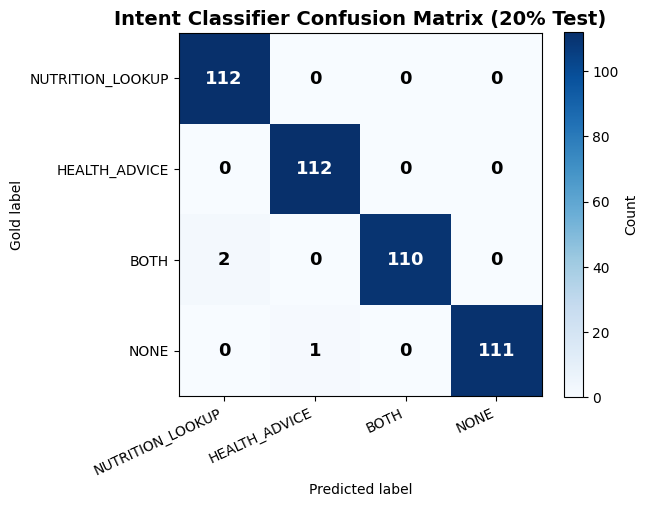

Saved: reports/en/intent_v2_standard_split/standard_split_confusion_matrix_count_only.png


In [10]:
# Plot count-only confusion matrix for slide screenshot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Intent Classifier Confusion Matrix (20% Test)", fontsize=14, weight="bold")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Gold label")
ax.set_xticks(range(len(LABELS)), LABELS, rotation=25, ha="right")
ax.set_yticks(range(len(LABELS)), LABELS)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() * 0.5 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=13, weight="bold")
fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
out = Path("reports/en/intent_v2_standard_split/standard_split_confusion_matrix_count_only.png")
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", out)

In [11]:
# Save model + metrics
out_dir = Path("models/classifier_bert_standard_split")
out_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(out_dir)
tokenizer.save_pretrained(out_dir)
summary = {
    "dataset": "data/en/intent_v2/intent_train_v2.csv",
    "split": "stratified 80/20",
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "accuracy": float(acc),
    "macro_f1": float(macro),
    "labels": LABELS,
    "confusion_matrix": cm.tolist(),
}
path = Path("reports/en/intent_v2_standard_split/standard_split_metrics.json")
path.parent.mkdir(parents=True, exist_ok=True)
path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print("Saved model:", out_dir)
print("Saved metrics:", path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model: models/classifier_bert_standard_split
Saved metrics: reports/en/intent_v2_standard_split/standard_split_metrics.json


In [12]:
import shutil
from google.colab import files

print("Đang nén mô hình...")
# Nén thư mục chứa model lại thành file ZIP
shutil.make_archive("intent_model_v2", "zip", "models/classifier_bert_standard_split")

print("Đang tải về máy tính của bạn...")
# Tự động kích hoạt tải file ZIP về trình duyệt
files.download("intent_model_v2.zip")


Đang nén mô hình...
Đang tải về máy tính của bạn...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>